In [1]:
%pip install python-louvain


  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9407 sha256=9df0cee763ae2b549c7621ee1e5b221611f27cca83a58e94def1bf8e6388cd38
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\af\40\91\ef3635f7d3ddbd889b5af9f1ac22b8d30c48d6f744cd74a6d1
Successfully built python-louvain
Note: you may need to restart the kernel to use updated packages.


# Анализ пространственной организации дендритов

### Загрузка и обработка данных

Если дендриты не обрабатывались ранее:

- в переменную `parent_folders` необходимо записать `[<Название папки с дендритами типа Ab>, <Название папки с дендритами типа Wt>]`

In [1]:
from dendrite_analysis import DendrAnalysis
import seaborn as sns
from notebook_widgets import SpineMeshDataset
import os

# parent_folders = ["Ab_test", "Wt_old"]
parent_folders = ["Ab_output", "Wt_output"]
# parent_folders = ["Ab_test", "Wt_test"]
dendr_group = []

for parent_folder in parent_folders:
    subfolder_paths = [
        os.path.join(parent_folder, name) for name in os.listdir(parent_folder)
        if os.path.isdir(os.path.join(parent_folder, name))
    ]
    
    scale = (1, 1, 1)
    spine_dataset_list = []

    for dataset_path in subfolder_paths:
        # load and scale spine mesh dataset
        spine_dataset = SpineMeshDataset().load(dataset_path)
        spine_dataset_list.append(spine_dataset)
        
    dendr_group.append(spine_dataset_list)

dendr_dataset = DendrAnalysis(dendr_group)

c:\Users\User\anaconda3\envs\spine-analysis\lib\site-packages\libpysal\weights\util.py:23: UserWarning: geopandas not available. Some functionality will be disabled.
  warn("geopandas not available. Some functionality will be disabled.")


KeyboardInterrupt: 

Если дендриты уже были обработаны ранее:
- в папку `input` необходимо положить следующие файлы (примеры всех файлов находятся в папке `examples/input`): 
    - `spine_coords.json` - координаты шипиков
    - `spine_metrics.json` - морфологические метрики шипиков
    - `dendr_metrics.json` - морфологические метрики дендритов (объем, длина, радиус)


In [1]:
from dendrite_analysis import DendrAnalysis

dendr_dataset = DendrAnalysis()

c:\Users\User\anaconda3\envs\spine-analysis\lib\site-packages\libpysal\weights\util.py:23: UserWarning: geopandas not available. Some functionality will be disabled.
  warn("geopandas not available. Some functionality will be disabled.")


DendrType init
OneDendrType init
Dendrite init
Spine init
Spine init
Spine init
Dendrite init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Dendrite init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Dendrite init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Dendrite init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Dendrite init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Spine init
Dendrite init
Spine init
Spine init


### Вычисление метрик 

- результаты вычисления метрик будут сохранены в папку `output`

In [3]:
dendr_dataset

In [3]:
# вычисление метрик организации дендрита - nndist, pcf, moran
dendr_dataset.calculate_grouping_metrics()
dendr_dataset.save_grouping_metrics()

  nndist =  4.225158183132397
  nndist_norm =  1.9162922384471106
  Значение коэффициента автокорреляции Moran's I для исходных координат:
     - Moran's I: -0.731, z_score: -1.3456, p-value: 0.1784
  nndist =  3.9255105952580287
  nndist_norm =  1.7803890788434276
  Значение коэффициента автокорреляции Moran's I для цилиндрических координат:


c:\Users\User\anaconda3\envs\spine-analysis\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 3 islands with ids: 0, 1, 2.
  warnings.warn(message)
c:\Katerina\unik\dendrclass\dendr_gitlab\dendrstatistics\dendrite_metrics.py:3064: RuntimeWarning: divide by zero encountered in long_scalars
  I = (n / W_sum) * (num / denom)
c:\Katerina\unik\dendrclass\dendr_gitlab\dendrstatistics\dendrite_metrics.py:3064: RuntimeWarning: invalid value encountered in double_scalars
  I = (n / W_sum) * (num / denom)
c:\Users\User\anaconda3\envs\spine-analysis\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 3 islands with ids: 0, 1, 2.
  warnings.warn(message)
c:\Users\User\anaconda3\envs\spine-analysis\lib\site-packages\esda\moran.py:218: RuntimeWarning: invalid value encountered in double_scal

('WARNING: ', 0, ' is an island (no neighbors)')
('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 2, ' is an island (no neighbors)')
     - Moran's I: -0.426, z_score: -0.2059, p-value: 0.8369
  nndist =  15.885461514319527
  nndist_norm =  5.821408980925376
  Значение коэффициента автокорреляции Moran's I для исходных координат:
('WARNING: ', 0, ' is an island (no neighbors)')
('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 2, ' is an island (no neighbors)')
     - Moran's I: nan, z_score: nan, p-value: nan
  nndist =  15.453413174175052
  nndist_norm =  5.663079927328555
  Значение коэффициента автокорреляции Moran's I для цилиндрических координат:
('WARNING: ', 0, ' is an island (no neighbors)')
('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 2, ' is an island (no neighbors)')
     - Moran's I: nan, z_score: nan, p-value: nan
  nndist =  4.716127495589086
  nndist_norm =  1.8051121299661448
  Значение коэффициента автокорреляции Moran's I 

c:\Users\User\anaconda3\envs\spine-analysis\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  warnings.warn(message)
c:\Users\User\anaconda3\envs\spine-analysis\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
 There are 7 islands with ids: 2, 3, 4, 5, 6, 7, 8.
  warnings.warn(message)


     - Moran's I: -0.543, z_score: -1.1955, p-value: 0.2319
  nndist =  4.3648333474282826
  nndist_norm =  1.670653227270177
  Значение коэффициента автокорреляции Moran's I для цилиндрических координат:
('WARNING: ', 2, ' is an island (no neighbors)')
('WARNING: ', 3, ' is an island (no neighbors)')
('WARNING: ', 4, ' is an island (no neighbors)')
('WARNING: ', 5, ' is an island (no neighbors)')
('WARNING: ', 6, ' is an island (no neighbors)')
('WARNING: ', 7, ' is an island (no neighbors)')
('WARNING: ', 8, ' is an island (no neighbors)')
     - Moran's I: -0.185, z_score: -0.0625, p-value: 0.9502
  nndist =  6.194970462765648
  nndist_norm =  2.487608091325288
  Значение коэффициента автокорреляции Moran's I для исходных координат:
     - Moran's I: -0.062, z_score: 0.3529, p-value: 0.7242
  nndist =  5.54550218221405
  nndist_norm =  2.226812247427429
  Значение коэффициента автокорреляции Moran's I для цилиндрических координат:
('WARNING: ', 3, ' is an island (no neighbors)')
('W

...

c:\Users\User\anaconda3\envs\spine-analysis\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 14 disconnected components.
 There are 12 islands with ids: 0, 1, 4, 5, 6, 8, 9, 10, 11, 13, 14, 15.
  warnings.warn(message)


     - Moran's I: -0.629, z_score: -0.9588, p-value: 0.3377
  nndist =  4.14107839167926
  nndist_norm =  2.865416642276069
  Значение коэффициента автокорреляции Moran's I для цилиндрических координат:
('WARNING: ', 2, ' is an island (no neighbors)')
     - Moran's I: -0.647, z_score: -0.9055, p-value: 0.3652
  nndist =  7.561777217991033
  nndist_norm =  4.088997625831421
  Значение коэффициента автокорреляции Moran's I для исходных координат:
('WARNING: ', 4, ' is an island (no neighbors)')
('WARNING: ', 6, ' is an island (no neighbors)')


c:\Users\User\anaconda3\envs\spine-analysis\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 2 islands with ids: 4, 6.
  warnings.warn(message)


     - Moran's I: 0.060, z_score: 0.4916, p-value: 0.6230
  nndist =  7.501801208026876
  nndist_norm =  4.0565658633924535
  Значение коэффициента автокорреляции Moran's I для цилиндрических координат:
('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 3, ' is an island (no neighbors)')
('WARNING: ', 4, ' is an island (no neighbors)')
('WARNING: ', 5, ' is an island (no neighbors)')
('WARNING: ', 6, ' is an island (no neighbors)')
     - Moran's I: -0.838, z_score: -0.7554, p-value: 0.4500
  nndist =  2.0915837346267145
  nndist_norm =  2.087745046307631
  Значение коэффициента автокорреляции Moran's I для исходных координат:
     - Moran's I: -0.332, z_score: -1.4325, p-value: 0.1520
  nndist =  1.8573065526372217
  nndist_norm =  1.853897833755671
  Значение коэффициента автокорреляции Moran's I для цилиндрических координат:
     - Moran's I: -0.339, z_score: -0.5390, p-value: 0.5899
  nndist =  4.856997420018519
  nndist_norm =  2.308895371139562
  Значение коэффициента

c:\Users\User\anaconda3\envs\spine-analysis\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 16 disconnected components.
 There are 13 islands with ids: 0, 1, 3, 4, 5, 7, 9, 11, 12, 13, 14, 15, 17.
  warnings.warn(message)


In [2]:
# выполнение кластеризации, вычисление метрик кластеризуемости
dendr_dataset.calculate_cluster_metrics()
dendr_dataset.save_cluster_metrics()


-----------------------------------------------------
Кластеризация DBSCAN для классических трехмерных координат
-----------------------------------------------------
   Автоматический подбор параметров DBSCAN с помощью теста Крускала-Уоллиса...
eps =  4.223681288679029


NameError: name 'csgraph' is not defined

Если метрики были посчитаны ранее:
- в папку input необходимо положить файлы `grouping_dendr_metrics.json` и `cluster_dendr_metrics.json` соответственно (примеры файлов в папке `examples/input`)

In [2]:
# загрузка метрик организации дендритов из файла - nndist, pcf, moran
dendr_dataset.load_grouping_metrics() 

In [3]:
# загрузка метрик кластеризуемости дендритов из файла
dendr_dataset.load_cluster_metrics() 

**ВАЖНО!** Анализ пространственных кластеров и окрестностей возможен только при наличии морфологических классов и кластеров у шипиков

Для того, чтобы загрузить данные по классификации и кластеризации шипиков необходимо:
- в папку `input` положить файлы `classification.csv` и `clusterization.csv`
- запустить код из ячеек ниже

In [4]:
dendr_dataset.add_spine_class() # добавить данные по классификации 
dendr_dataset.add_spine_cluster() # добавить данные по кластеризации 

In [2]:
# анализ кластеров, полученных в результате кластеризации (получение матрицы вероятности взаимного расположения шипиков разных типов)
dendr_dataset.cluster_analysis()

AttributeError: 'list' object has no attribute 'size'

In [13]:
# анализ окрестностей (получение матрицы вероятности взаимного расположения шипиков разных типов)

# eps = dbscan_eps
# dendr_dataset.neighborhood_analysis() 

# eps = 5 (на основании статьи hotspot)
dendr_dataset.neighborhood_analysis(5) 

# eps = значение первого пика pcf = 2 
# dendr_dataset.neighborhood_analysis(2)

Точка 0 (Ab+9009/24-1/spine_0.off - ик [7.2778759584145565, 7.117808284600391, 1.9700242040285896]): соседи [0 1 2]
Точка 0 (Ab+9009/24-1/spine_0.off - цк [0.8178180953157829, 1.9593629069127634, 0.13184202173491055]): соседи [<dendrite_metrics.Spine object at 0x000001712644FC70>, <dendrite_metrics.Spine object at 0x000001712644F970>, <dendrite_metrics.Spine object at 0x000001712644FEE0>, <dendrite_metrics.Spine object at 0x000001712644FEB0>]


AttributeError: 'Spine' object has no attribute 'class_type'

In [2]:
dendr_dataset.graph_analysis()
dendr_dataset.save_graph_metrics()

[3.0, 5.0, 8.0, 3.0, 5.333333333333333, 4.0, 4.0, 4.5, 3.6666666666666665, 4.0, 4.666666666666667, 4.0, 4.5, 4.0, 7.333333333333333, 5.666666666666667, 3.3333333333333335, 6.333333333333333, 4.666666666666667, 4.666666666666667, 6.333333333333333, 3.3333333333333335, 4.0, 5.0]
[3.0, 4.0, 3.0, 4.0, 4.666666666666667, 3.3333333333333335, 3.5, 2.3333333333333335, 3.0, 2.6666666666666665, 4.5, 3.5, 5.0, 2.6666666666666665, 4.666666666666667, 5.0, 3.6666666666666665, 2.6666666666666665, 2.5, 3.0, 3.0, 3.0, 6.0, 4.333333333333333, 0, 2.6666666666666665, 4.5, 3.5, 3.0, 6.0, 3.6666666666666665, 3.5, 4.5, 2.5, 0, 4.0, 3.3333333333333335]


### Сравнение метрик

--------------------------------------------------------------------------
Метрика NNdist 
(цилиндрические координаты)
   wt_mean =  5.645879878614633
   ab_mean =  4.936046853310744
   wt_median =  5.436108928420954
   ab_median =  4.1115600467375675

wt дополнительная статистика:
   wt_Q1 = 4.03
   wt_Q3 = 7.67
   wt_IQR = 3.64
   wt_median - IQR = 1.80
   wt_median + IQR = 9.07
   wt_min = 1.86
   wt_max = 9.60

ab дополнительная статистика:
   ab_Q1 = 3.48
   ab_Q3 = 5.39
   ab_IQR = 1.91
   ab_median - IQR = 2.20
   ab_median + IQR = 6.02
   ab_min = 2.02
   ab_max = 15.45
График сохранен в файл: graphics/9009 Гистограмма - Метрика NNdist (цилиндрические координаты).png


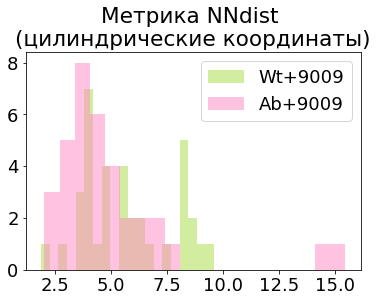

Статистика теста: 0.2896825396825397
P-значение: 0.08643731323771808
График сохранен в файл: graphics/9009 Метрика NNdist (цилиндрические координаты).png


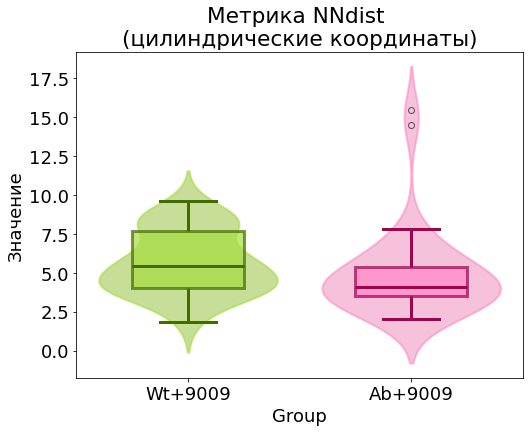

--------------------------------------------------------------------------
Нормализованная метрика NNdist 
(цилиндрические координаты)
   wt_mean =  2.702243656640457
   ab_mean =  2.557743729111367
   wt_median =  2.4600318670391337
   ab_median =  2.351680980766543

wt дополнительная статистика:
   wt_Q1 = 2.17
   wt_Q3 = 3.16
   wt_IQR = 0.99
   wt_median - IQR = 1.47
   wt_median + IQR = 3.45
   wt_min = 1.60
   wt_max = 5.65

ab дополнительная статистика:
   ab_Q1 = 1.94
   ab_Q3 = 2.77
   ab_IQR = 0.83
   ab_median - IQR = 1.53
   ab_median + IQR = 3.18
   ab_min = 1.43
   ab_max = 5.66
График сохранен в файл: graphics/9009 Гистограмма - Нормализованная метрика NNdist (цилиндрические координаты).png


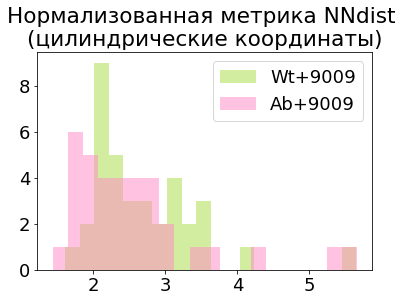

Статистика теста: 0.25952380952380955
P-значение: 0.15692320469251053
График сохранен в файл: graphics/9009 Нормализованная метрика NNdist (цилиндрические координаты).png


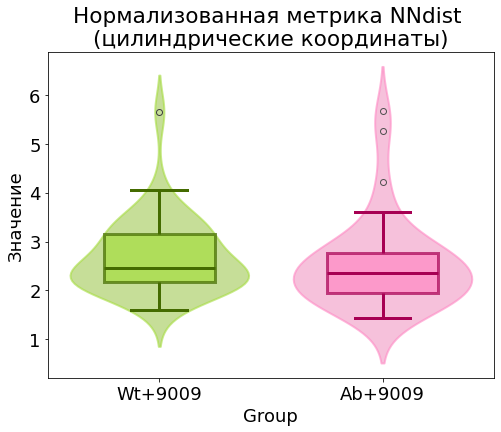

--------------------------------------------------------------------------
Энтропия Шеннона для метрики PCF 
(цилиндрические координаты)
   wt_mean =  2.7689392897887246
   ab_mean =  2.9787107405324944
   wt_median =  2.8134733775367744
   ab_median =  2.9460154769485007

wt дополнительная статистика:
   wt_Q1 = 2.17
   wt_Q3 = 3.24
   wt_IQR = 1.07
   wt_median - IQR = 1.75
   wt_median + IQR = 3.88
   wt_min = 1.10
   wt_max = 4.12

ab дополнительная статистика:
   ab_Q1 = 2.61
   ab_Q3 = 3.57
   ab_IQR = 0.96
   ab_median - IQR = 1.99
   ab_median + IQR = 3.90
   ab_min = 1.10
   ab_max = 4.03
График сохранен в файл: graphics/9009 Гистограмма - Энтропия Шеннона для метрики PCF (цилиндрические координаты).png


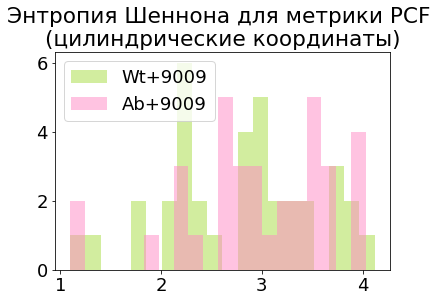

Статистика теста: 0.21666666666666667
P-значение: 0.2990857974698746
График сохранен в файл: graphics/9009 Энтропия Шеннона для метрики PCF (цилиндрические координаты).png


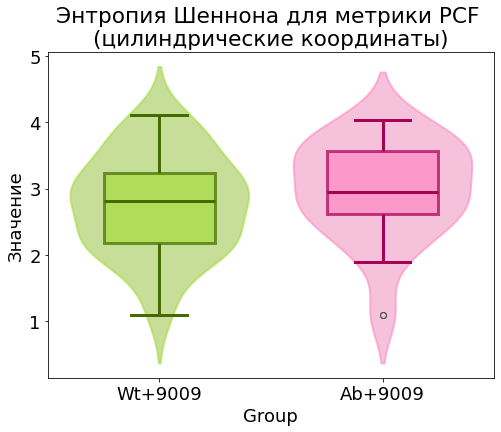

--------------------------------------------------------------------------
Индекс Морана I 
(цилиндрические координаты)
   wt_mean =  -0.12411293322483737
   ab_mean =  -0.031021027188578316
   wt_median =  -0.13667897663582185
   ab_median =  0.024674122178932008

wt дополнительная статистика:
   wt_Q1 = -0.33
   wt_Q3 = 0.08
   wt_IQR = 0.40
   wt_median - IQR = -0.54
   wt_median + IQR = 0.26
   wt_min = -0.72
   wt_max = 0.38

ab дополнительная статистика:
   ab_Q1 = -0.23
   ab_Q3 = 0.12
   ab_IQR = 0.35
   ab_median - IQR = -0.33
   ab_median + IQR = 0.38
   ab_min = -0.63
   ab_max = 0.55
График сохранен в файл: graphics/9009 Гистограмма - Индекс Морана I (цилиндрические координаты).png


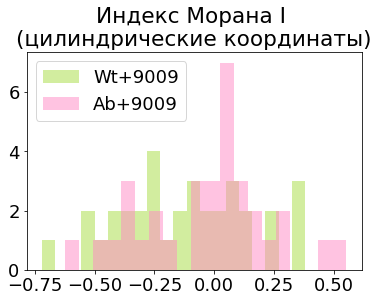

Статистика теста: 0.28342245989304815
P-значение: 0.10751464015629708
График сохранен в файл: graphics/9009 Индекс Морана I (цилиндрические координаты).png


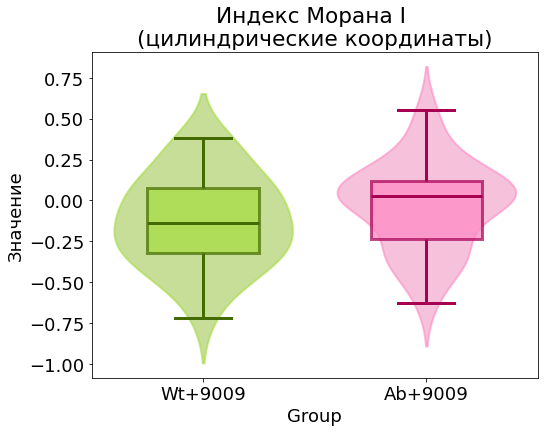

--------------------------------------------------------------------------
Индекс Морана zI 
(цилиндрические координаты)
   wt_mean =  0.04085732994895414
   ab_mean =  0.3200907614768583
   wt_median =  0.0
   ab_median =  0.19671823094015325

wt дополнительная статистика:
   wt_Q1 = -0.57
   wt_Q3 = 0.66
   wt_IQR = 1.24
   wt_median - IQR = -1.24
   wt_median + IQR = 1.24
   wt_min = -2.67
   wt_max = 1.80

ab дополнительная статистика:
   ab_Q1 = -0.13
   ab_Q3 = 0.70
   ab_IQR = 0.83
   ab_median - IQR = -0.63
   ab_median + IQR = 1.03
   ab_min = -1.76
   ab_max = 2.88
График сохранен в файл: graphics/9009 Гистограмма - Индекс Морана zI (цилиндрические координаты).png


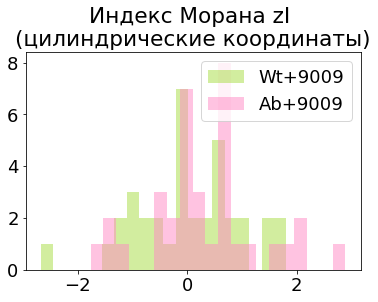

Статистика теста: 0.19126984126984126
P-значение: 0.43827771950267713
График сохранен в файл: graphics/9009 Индекс Морана zI (цилиндрические координаты).png


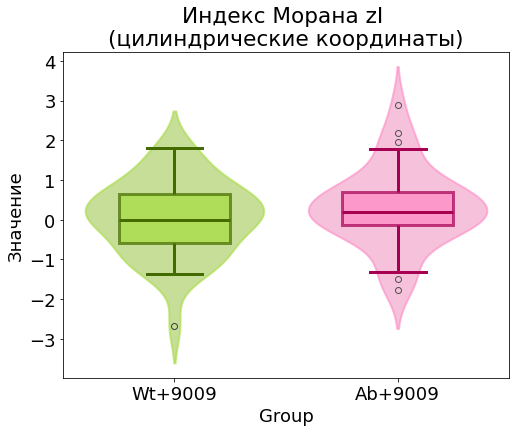

--------------------------------------------------------------------------
Индекс Морана p_value 
(цилиндрические координаты)
   wt_mean =  0.37099783026389715
   ab_mean =  0.44098845020581917
   wt_median =  0.36080314804599023
   ab_median =  0.5162513254843928

wt дополнительная статистика:
   wt_Q1 = 0.11
   wt_Q3 = 0.59
   wt_IQR = 0.48
   wt_median - IQR = -0.12
   wt_median + IQR = 0.84
   wt_min = 0.00
   wt_max = 0.98

ab дополнительная статистика:
   ab_Q1 = 0.10
   ab_Q3 = 0.70
   ab_IQR = 0.60
   ab_median - IQR = -0.08
   ab_median + IQR = 1.11
   ab_min = 0.00
   ab_max = 0.95
График сохранен в файл: graphics/9009 Гистограмма - Индекс Морана p_value (цилиндрические координаты).png


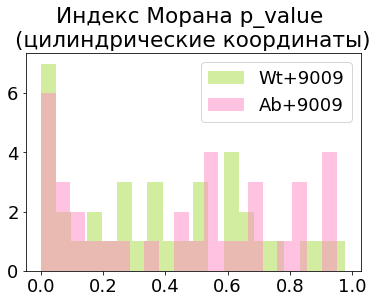

Статистика теста: 0.20873015873015874
P-значение: 0.36241934761766037
График сохранен в файл: graphics/9009 Индекс Морана p_value (цилиндрические координаты).png


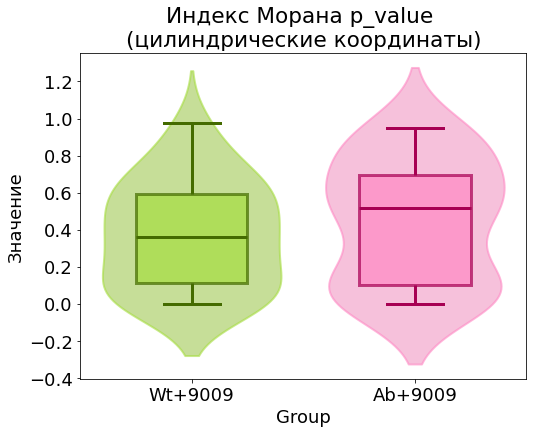

In [4]:
# сравнение метрик организации дендритов - nndist, pcf, moran (Wt/Ab)
dendr_dataset.compare_grouping_metrics()

--------------------------------------------------------------------------
Процент шума при оптимальных параметрах кластеризации DBSCAN 
(исходные координаты)
   wt_mean =  0.24570129553682188
   ab_mean =  0.19587158447041528
   wt_median =  0.2
   ab_median =  0.11764705882352941

wt дополнительная статистика:
   wt_Q1 = 0.04
   wt_Q3 = 0.29
   wt_IQR = 0.25
   wt_median - IQR = -0.05
   wt_median + IQR = 0.45
   wt_min = 0.00
   wt_max = 1.00

ab дополнительная статистика:
   ab_Q1 = 0.00
   ab_Q3 = 0.19
   ab_IQR = 0.19
   ab_median - IQR = -0.07
   ab_median + IQR = 0.31
   ab_min = 0.00
   ab_max = 1.00
График сохранен в файл: graphics/9009 Гистограмма - Процент шума при оптимальных параметрах кластеризации DBSCAN (исходные координаты).png


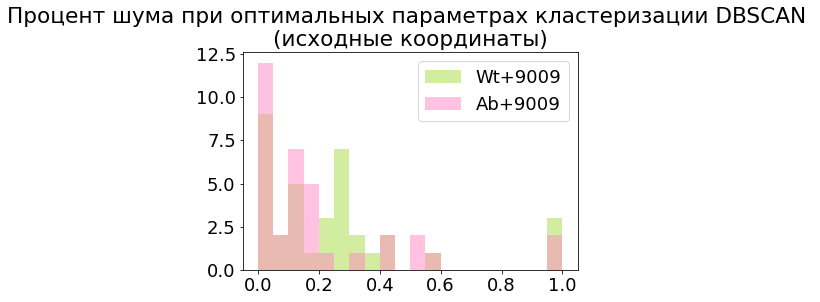

Статистика теста: 0.2706349206349206
P-значение: 0.11186891743961402
График сохранен в файл: graphics/9009 Процент шума при оптимальных параметрах кластеризации DBSCAN (исходные координаты).png


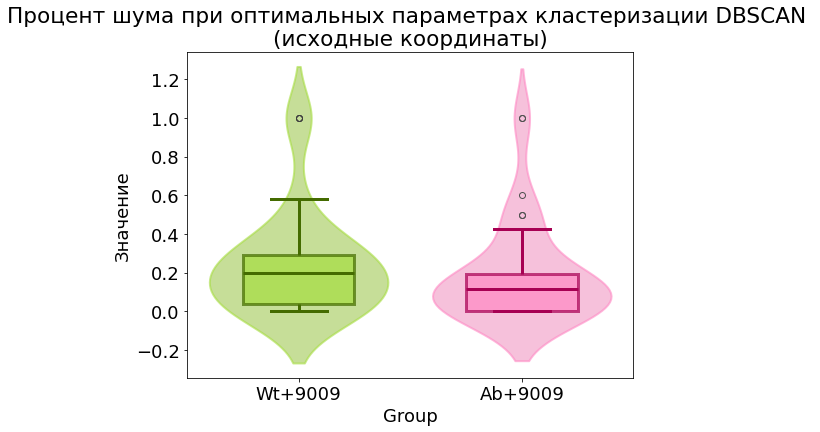

--------------------------------------------------------------------------
Оптимальный параметр eps для кластеризации DBSCAN 
(цилиндрические координаты)
   wt_mean =  3.427777777777778
   ab_mean =  3.414285714285714
   wt_median =  3.2000000000000015
   ab_median =  3.2000000000000015

wt дополнительная статистика:
   wt_Q1 = 2.50
   wt_Q3 = 4.30
   wt_IQR = 1.80
   wt_median - IQR = 1.40
   wt_median + IQR = 5.00
   wt_min = 0.90
   wt_max = 7.20

ab дополнительная статистика:
   ab_Q1 = 2.50
   ab_Q3 = 4.00
   ab_IQR = 1.50
   ab_median - IQR = 1.70
   ab_median + IQR = 4.70
   ab_min = 1.50
   ab_max = 6.60
График сохранен в файл: graphics/9009 Гистограмма - Оптимальный параметр eps для кластеризации DBSCAN (цилиндрические координаты).png


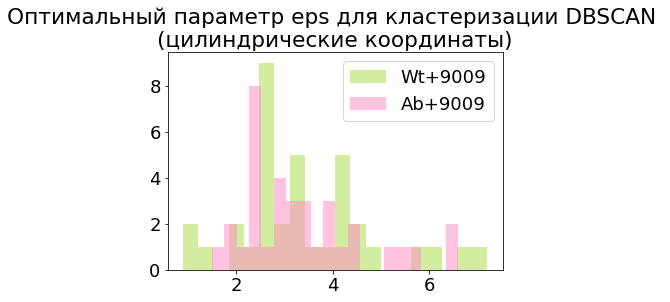

Статистика теста: 0.10476190476190476
P-значение: 0.9694254501226932
График сохранен в файл: graphics/9009 Оптимальный параметр eps для кластеризации DBSCAN (цилиндрические координаты).png


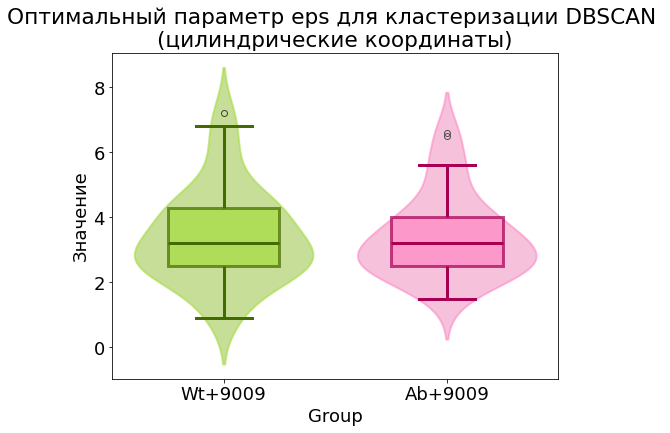

--------------------------------------------------------------------------
Оптимальный параметр min_samples для кластеризации DBSCAN 
(цилиндрические координаты)
   wt_mean =  2.2222222222222223
   ab_mean =  2.4285714285714284
   wt_median =  2.0
   ab_median =  2.0

wt дополнительная статистика:
   wt_Q1 = 2.00
   wt_Q3 = 2.00
   wt_IQR = 0.00
   wt_median - IQR = 2.00
   wt_median + IQR = 2.00
   wt_min = 2.00
   wt_max = 5.00

ab дополнительная статистика:
   ab_Q1 = 2.00
   ab_Q3 = 2.00
   ab_IQR = 0.00
   ab_median - IQR = 2.00
   ab_median + IQR = 2.00
   ab_min = 2.00
   ab_max = 5.00
График сохранен в файл: graphics/9009 Гистограмма - Оптимальный параметр min_samples для кластеризации DBSCAN (цилиндрические координаты).png


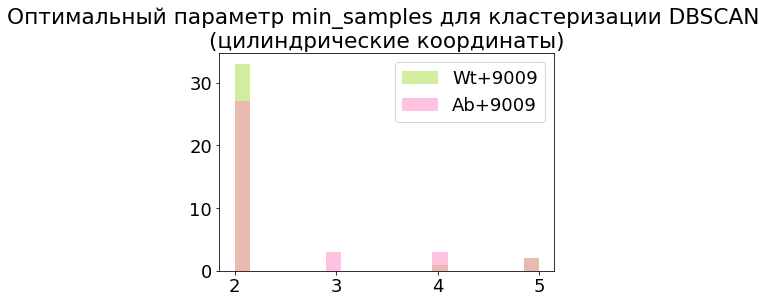

Статистика теста: 0.14523809523809525
P-значение: 0.7874047336820023
График сохранен в файл: graphics/9009 Оптимальный параметр min_samples для кластеризации DBSCAN (цилиндрические координаты).png


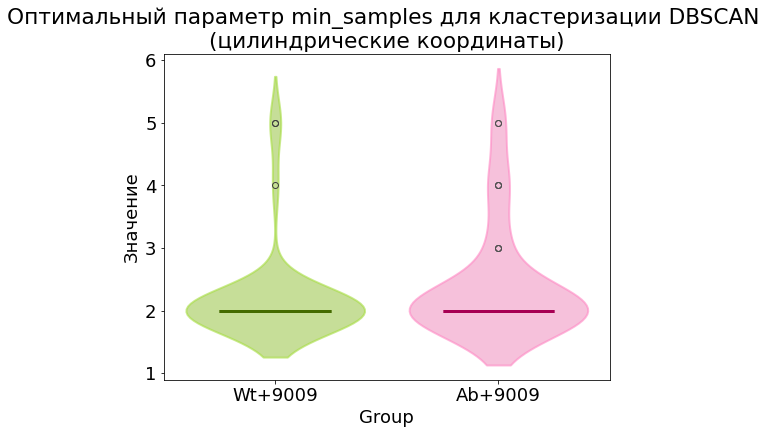

--------------------------------------------------------------------------
Статистика при оптимальных параметрах кластеризации DBSCAN 
(цилиндрические координаты)
   wt_mean =  1.907592256599609
   ab_mean =  2.5344254550304965
   wt_median =  1.0238095238095237
   ab_median =  2.3999999999999986

wt дополнительная статистика:
   wt_Q1 = 0.30
   wt_Q3 = 2.83
   wt_IQR = 2.53
   wt_median - IQR = -1.51
   wt_median + IQR = 3.55
   wt_min = 0.00
   wt_max = 6.86

ab дополнительная статистика:
   ab_Q1 = 0.77
   ab_Q3 = 3.46
   ab_IQR = 2.68
   ab_median - IQR = -0.28
   ab_median + IQR = 5.08
   ab_min = 0.00
   ab_max = 6.97
График сохранен в файл: graphics/9009 Гистограмма - Статистика при оптимальных параметрах кластеризации DBSCAN (цилиндрические координаты).png


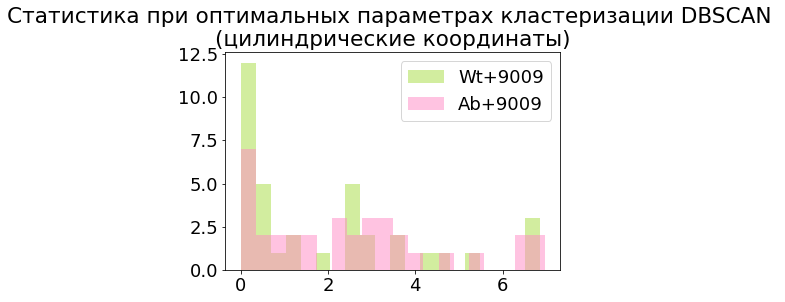

Статистика теста: 0.24365079365079365
P-значение: 0.18730660992788983
График сохранен в файл: graphics/9009 Статистика при оптимальных параметрах кластеризации DBSCAN (цилиндрические координаты).png


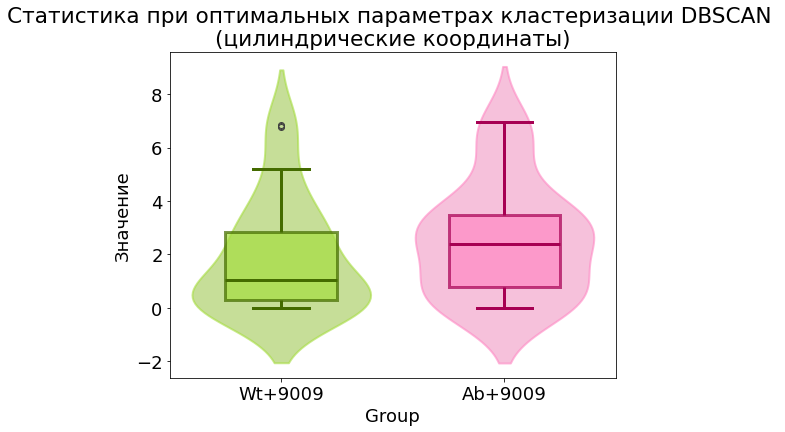

--------------------------------------------------------------------------
P-value при оптимальных параметрах кластеризации DBSCAN 
(цилиндрические координаты)
   wt_mean =  0.2555081221722142
   ab_mean =  0.16256716261930912
   wt_median =  0.1387266478372275
   ab_median =  0.095580704545629

wt дополнительная статистика:
   wt_Q1 = 0.06
   wt_Q3 = 0.50
   wt_IQR = 0.44
   wt_median - IQR = -0.30
   wt_median + IQR = 0.58
   wt_min = 0.00
   wt_max = 1.00

ab дополнительная статистика:
   ab_Q1 = 0.06
   ab_Q3 = 0.20
   ab_IQR = 0.14
   ab_median - IQR = -0.04
   ab_median + IQR = 0.23
   ab_min = 0.00
   ab_max = 0.77
График сохранен в файл: graphics/9009 Гистограмма - P-value при оптимальных параметрах кластеризации DBSCAN (цилиндрические координаты).png


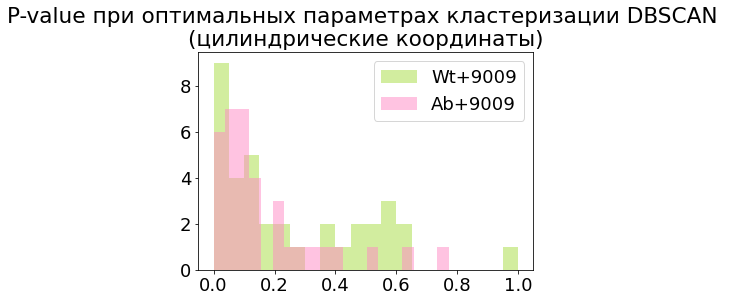

Статистика теста: 0.21984126984126984
P-значение: 0.2769119452313149
График сохранен в файл: graphics/9009 P-value при оптимальных параметрах кластеризации DBSCAN (цилиндрические координаты).png


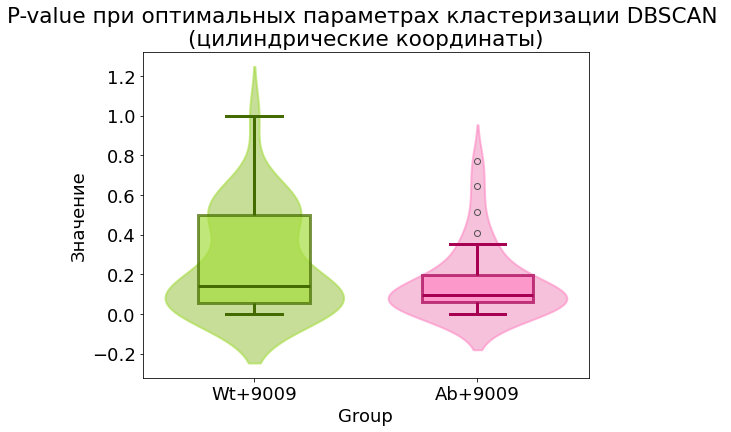

--------------------------------------------------------------------------
Процент шума при оптимальных параметрах кластеризации DBSCAN 
(цилиндрические координаты)
   wt_mean =  0.23906288237428588
   ab_mean =  0.2334413805047711
   wt_median =  0.17894736842105263
   ab_median =  0.14285714285714285

wt дополнительная статистика:
   wt_Q1 = 0.11
   wt_Q3 = 0.33
   wt_IQR = 0.23
   wt_median - IQR = -0.05
   wt_median + IQR = 0.41
   wt_min = 0.00
   wt_max = 1.00

ab дополнительная статистика:
   ab_Q1 = 0.00
   ab_Q3 = 0.34
   ab_IQR = 0.34
   ab_median - IQR = -0.20
   ab_median + IQR = 0.48
   ab_min = 0.00
   ab_max = 1.00
График сохранен в файл: graphics/9009 Гистограмма - Процент шума при оптимальных параметрах кластеризации DBSCAN (цилиндрические координаты).png


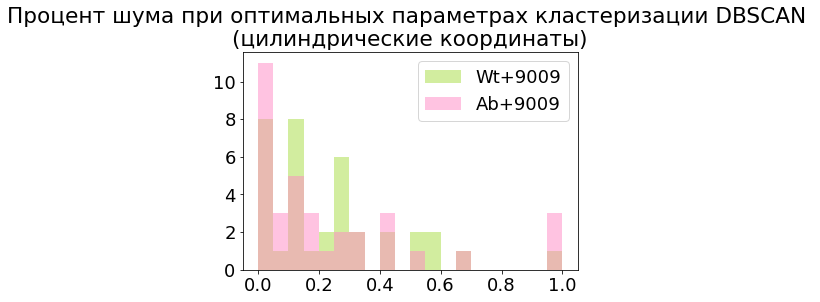

Статистика теста: 0.15
P-значение: 0.7517641897094605
График сохранен в файл: graphics/9009 Процент шума при оптимальных параметрах кластеризации DBSCAN (цилиндрические координаты).png


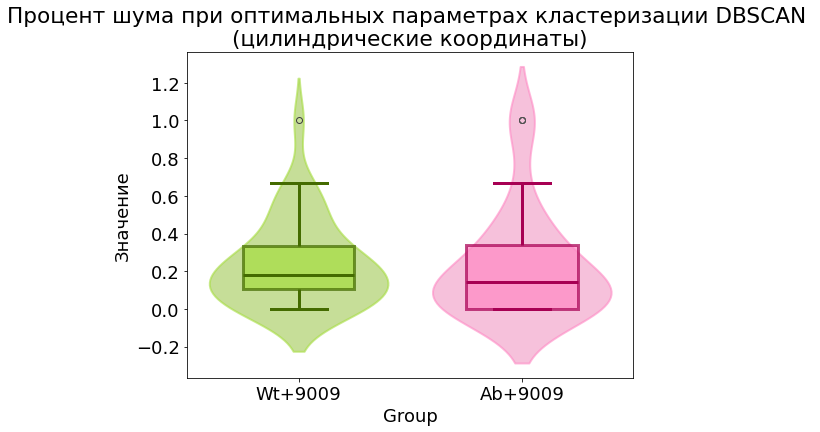

In [5]:
# сравнение метрик кластеризуемости дендритов
dendr_dataset.compare_cluster_metrics()

--------------------------------------------------------------------------
Средний размер подграфов 
(цилиндрические координаты)
   wt_mean =  3.824074074074074
   ab_mean =  4.045238095238095
   wt_median =  3.833333333333333
   ab_median =  4.0

wt дополнительная статистика:
   wt_Q1 = 3.00
   wt_Q3 = 4.50
   wt_IQR = 1.50
   wt_median - IQR = 2.33
   wt_median + IQR = 5.33
   wt_min = 2.00
   wt_max = 6.33

ab дополнительная статистика:
   ab_Q1 = 3.00
   ab_Q3 = 4.83
   ab_IQR = 1.83
   ab_median - IQR = 2.17
   ab_median + IQR = 5.83
   ab_min = 2.00
   ab_max = 7.00
График сохранен в файл: graphics/9009 Гистограмма - Средний размер подграфов (цилиндрические координаты).png


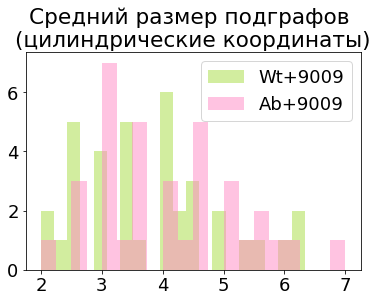

Статистика теста: 0.16507936507936508
P-значение: 0.6172369072344785
График сохранен в файл: graphics/9009 Средний размер подграфов (цилиндрические координаты).png


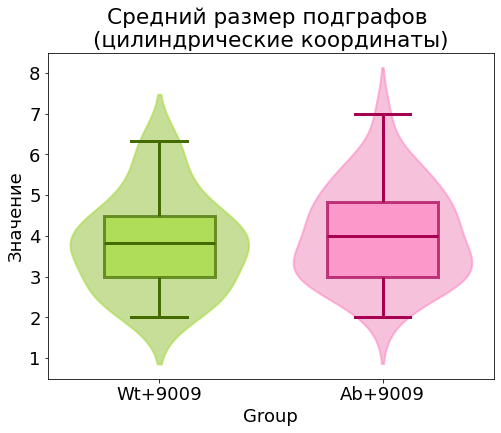

--------------------------------------------------------------------------
Средняя протяженность подграфов 
(цилиндрические координаты)
   wt_mean =  5.22938930129667
   ab_mean =  4.815652038956757
   wt_median =  4.920998708073977
   ab_median =  3.5240202356281993

wt дополнительная статистика:
   wt_Q1 = 3.99
   wt_Q3 = 6.18
   wt_IQR = 2.19
   wt_median - IQR = 2.73
   wt_median + IQR = 7.11
   wt_min = 1.93
   wt_max = 10.98

ab дополнительная статистика:
   ab_Q1 = 2.96
   ab_Q3 = 4.99
   ab_IQR = 2.04
   ab_median - IQR = 1.49
   ab_median + IQR = 5.56
   ab_min = 1.60
   ab_max = 20.55
График сохранен в файл: graphics/9009 Гистограмма - Средняя протяженность подграфов (цилиндрические координаты).png


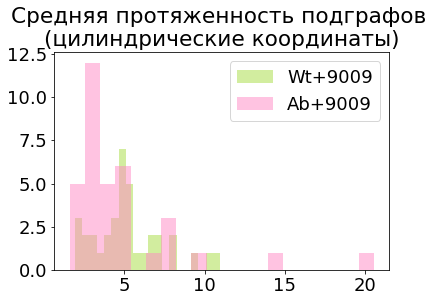

Статистика теста: 0.353968253968254
P-значение: 0.015795378636114132
График сохранен в файл: graphics/9009 Средняя протяженность подграфов (цилиндрические координаты).png


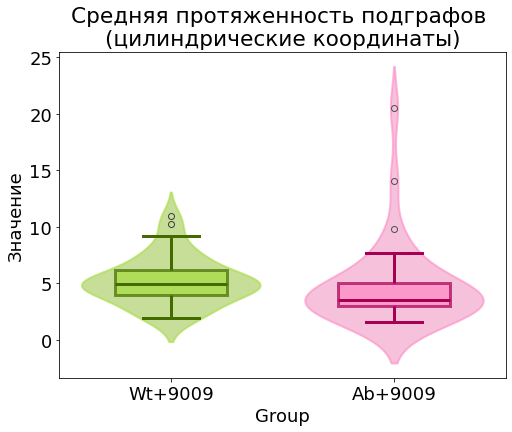

--------------------------------------------------------------------------
Средний коэффициент группировки 
(цилиндрические координаты)
   wt_mean =  0.24169595445596917
   ab_mean =  0.21871448465652904
   wt_median =  0.22485846639857587
   ab_median =  0.17162088355735206

wt дополнительная статистика:
   wt_Q1 = 0.15
   wt_Q3 = 0.32
   wt_IQR = 0.17
   wt_median - IQR = 0.06
   wt_median + IQR = 0.39
   wt_min = 0.03
   wt_max = 0.54

ab дополнительная статистика:
   ab_Q1 = 0.10
   ab_Q3 = 0.27
   ab_IQR = 0.17
   ab_median - IQR = -0.00
   ab_median + IQR = 0.34
   ab_min = 0.00
   ab_max = 0.63
График сохранен в файл: graphics/9009 Гистограмма - Средний коэффициент группировки (цилиндрические координаты).png


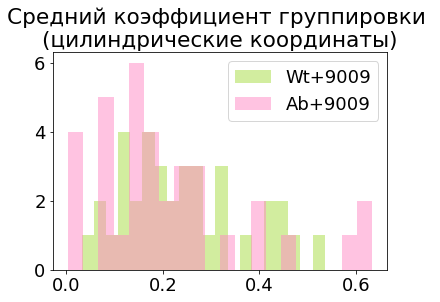

Статистика теста: 0.2373015873015873
P-значение: 0.22747978312545447
График сохранен в файл: graphics/9009 Средний коэффициент группировки (цилиндрические координаты).png


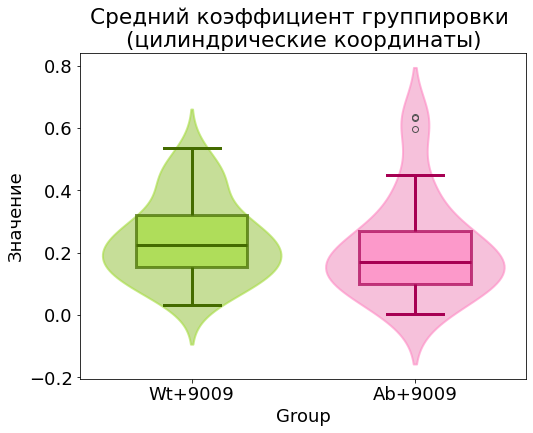

--------------------------------------------------------------------------
Модульность 
(цилиндрические координаты)
   wt_mean =  0.1609460708062637
   ab_mean =  0.19262890110477807
   wt_median =  0.1535816166112017
   ab_median =  0.18783638630235966

wt дополнительная статистика:
   wt_Q1 = 0.10
   wt_Q3 = 0.23
   wt_IQR = 0.13
   wt_median - IQR = 0.02
   wt_median + IQR = 0.29
   wt_min = -0.00
   wt_max = 0.36

ab дополнительная статистика:
   ab_Q1 = 0.12
   ab_Q3 = 0.27
   ab_IQR = 0.15
   ab_median - IQR = 0.04
   ab_median + IQR = 0.34
   ab_min = 0.00
   ab_max = 0.50
График сохранен в файл: graphics/9009 Гистограмма - Модульность (цилиндрические координаты).png


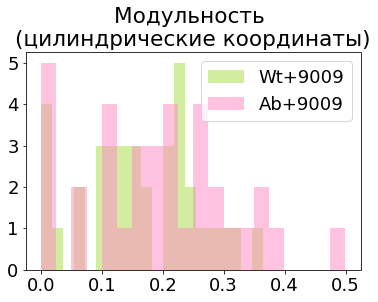

Статистика теста: 0.20476190476190476
P-значение: 0.3925497823835433
График сохранен в файл: graphics/9009 Модульность (цилиндрические координаты).png


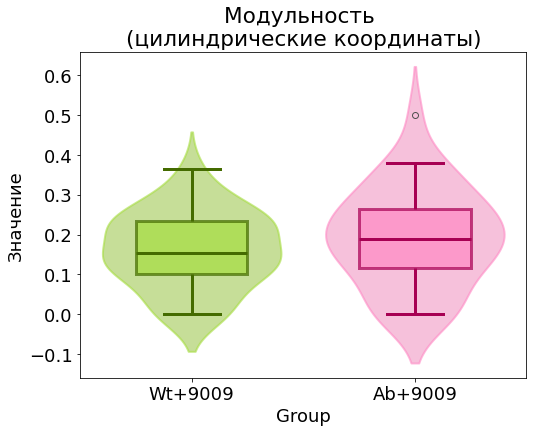

In [7]:
# сравнение метрик кластеризуемости дендритов
dendr_dataset.compare_graph_metrics()

### Сохранение всех метрик для классификации

Сохранение метрик с учетом матрицы вероятности (возможно только после проведения анализа пространственных кластеров и окрестностей)

In [8]:
dendr_dataset.save_dendr_metrics()

c:\Katerina\unik\dendrclass\dendr_gitlab\dendrstatistics\dendrite_metrics.py:872: RuntimeWarning: invalid value encountered in true_divide
  matrix = m / m.max()


Сохранение метрик без учета матриы вероятности

In [5]:
dendr_dataset.save_dendr_metrics_without_class_cluster()